In [43]:
!pip install pandas matplotlib seaborn

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
sentiment = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")

In [46]:
print("Sentiment Data:")
print(sentiment.head())

print("\nTrades Data:")
print(trades.head())

Sentiment Data:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trades Data:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1

In [47]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

In [48]:
sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['Timestamp IST'].dt.date

In [49]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

print("\nMerged Data:")
print(merged.head())


Merged Data:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID 

In [50]:
profit_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()
print("\nAverage PnL by Sentiment:")
print(profit_by_sentiment)


Average PnL by Sentiment:
classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [51]:
trade_count = merged['classification'].value_counts()
print("\nTrade Count by Sentiment:")
print(trade_count)


Trade Count by Sentiment:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


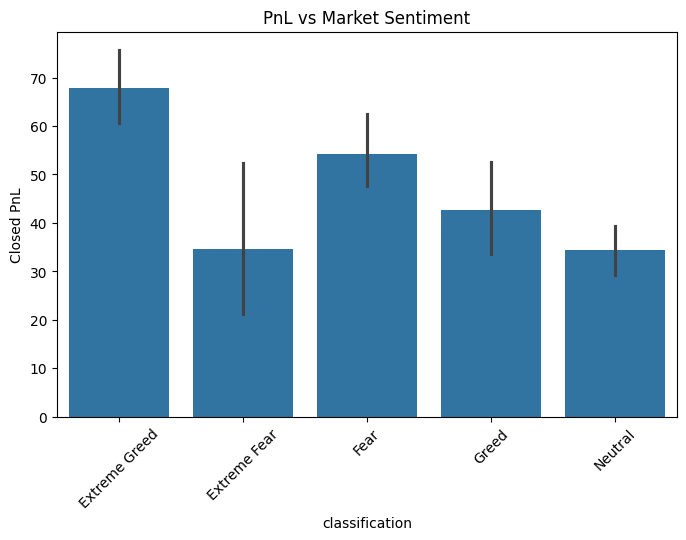

In [52]:
plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL vs Market Sentiment")
plt.xticks(rotation=45)

plt.savefig("pnl_vs_sentiment.png")
plt.show()

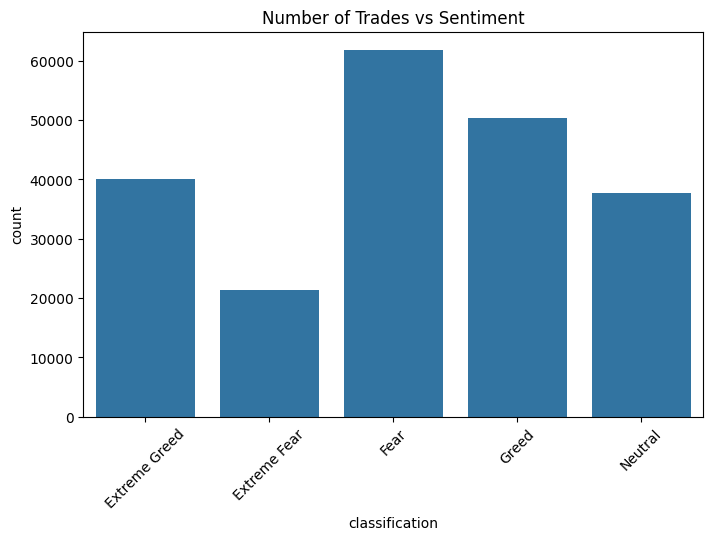

In [53]:
plt.figure(figsize=(8,5))
sns.countplot(x='classification', data=merged)
plt.title("Number of Trades vs Sentiment")
plt.xticks(rotation=45)

plt.savefig("trade_count.png")
plt.show()

In [54]:
buy_sell = pd.crosstab(merged['classification'], merged['Side'])
print("\nBuy vs Sell by Sentiment:")
print(buy_sell)


Buy vs Sell by Sentiment:
Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


In [55]:
avg_size = merged.groupby('classification')['Size USD'].mean()
print("\nAverage Trade Size:")
print(avg_size)


Average Trade Size:
classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


In [56]:
if 'leverage' in merged.columns:
    leverage_analysis = merged.groupby('classification')['leverage'].mean()
    print("\nAverage Leverage:")
    print(leverage_analysis)

In [57]:
merged['value'] = pd.to_numeric(merged['value'], errors='coerce')

correlation = merged[['Closed PnL', 'value']].corr()
print("\nCorrelation between Sentiment Index & PnL:")
print(correlation)



Correlation between Sentiment Index & PnL:
            Closed PnL     value
Closed PnL    1.000000  0.008121
value         0.008121  1.000000


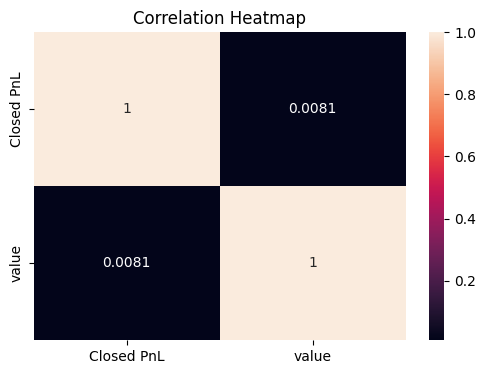

In [58]:
plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")
plt.show()